# Contract Clause Risk with NLP and Neural Networks
**Author:** Atul Iwale · **Project 5 upgrade** of the AEC Fieldwork portfolio

**Business question:** can we flag high-risk contract clauses from their *wording*, the way a legal reviewer would, before a contract is signed?

The original Project 5 app used a risk category that someone had already assigned. In practice that rating is the expensive part: a reviewer has to read every clause. This notebook trains models on **6,539 clauses from 1,300 historical contracts** rated by six legal reviewers, then tests them on the **800 clauses of the 200 live portfolio contracts** (synthetic data, patterned on Indian construction contracts).

**Contents**
1. Load and audit the data · 2. Clean and normalise text · 3. Explore the wording · 4. Train/test design
5. Baseline: keyword rules · 6. Classic NLP models (Naive Bayes, Logistic Regression, SVM) · 7. Neural networks (MLP, BiLSTM, 1D-CNN)
8. Results · 9. Tuning for high-risk recall · 10. Explainability · 11. Error analysis and label noise
12. Unsupervised: topic clusters (K-means) · 13. Key-term extraction · 14. Contract review worklist · 15. Export for the app

In [1]:
import os, re, json, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import chi2
import tensorflow as tf
pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 130)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42; tf.keras.utils.set_random_seed(SEED)
DATA = '../data/05_Contract_Lifecycle_Intelligence_v2.xlsx'
LEVELS = ['Low', 'Medium', 'High']

I0000 00:00:1790168161.309543    2460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790168163.784478    2460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load and audit the data

In [2]:
hc  = pd.read_excel(DATA, sheet_name='historical_contracts')
hcl = pd.read_excel(DATA, sheet_name='historical_clauses')
pc  = pd.read_excel(DATA, sheet_name='dim_contract')
pcl = pd.read_excel(DATA, sheet_name='fact_clause')
ak  = pd.read_excel(DATA, sheet_name='answer_key')
print(f'Historical library: {len(hc):,} contracts, {len(hcl):,} clauses, signed {hc.signed_date.min():%b %Y} to {hc.signed_date.max():%b %Y}')
print(f'Portfolio (Project 5): {len(pc)} contracts, {len(pcl)} clauses, starting {pc.start_date.min():%b %Y} to {pc.start_date.max():%b %Y}')
print('Missing clause text (unreadable scans):', hcl.clause_text.isna().sum(), '| duplicate clause IDs:', hcl.clause_id.duplicated().sum(),
      '| clauses with no contract:', (~hcl.contract_id.isin(hc.contract_id)).sum())
hcl.sample(3, random_state=1)[['clause_type', 'risk_level', 'clause_text']]

Historical library: 1,300 contracts, 6,539 clauses, signed Jan 2019 to Sep 2024
Portfolio (Project 5): 200 contracts, 800 clauses, starting Oct 2024 to Mar 2026
Missing clause text (unreadable scans): 26 | duplicate clause IDs: 0 | clauses with no contract: 0


,clause_type,risk_level,clause_text
6145,Indemnity,Medium,Each Party agrees to indemnify the other from and against any and all claims and liabilities to the extent of direct losses on...
5755,Termination,Medium,The Employer may terminate this Agreement for convenience at any time by giving 30 days written notice. A cure period of fifte...
2377,Auto-Renewal,Medium,"In accordance with the General Conditions of Contract, the Agreement renews automatically for a further 1 year unless cancelle..."


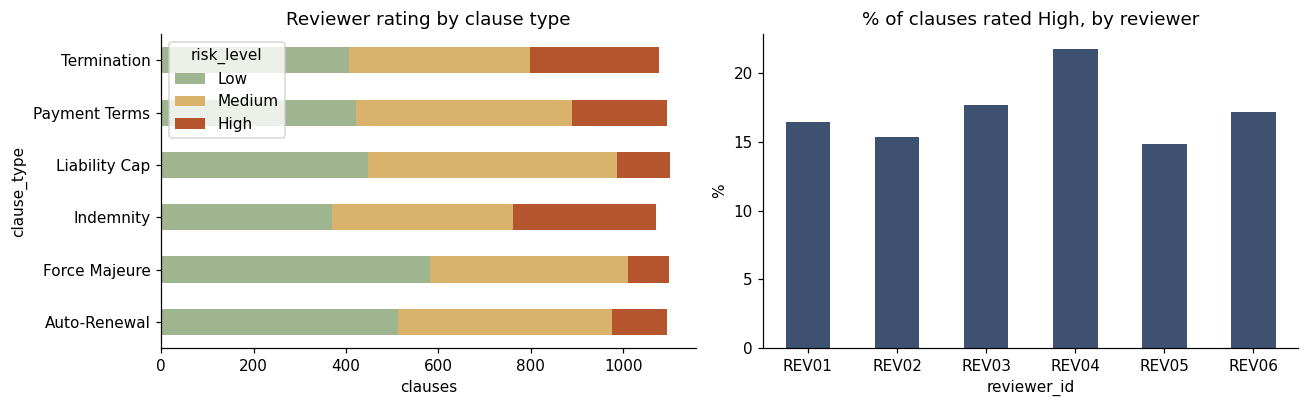

In [3]:
lab = hcl.merge(hc[['contract_id', 'reviewer_id']], on='contract_id')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
pd.crosstab(lab.clause_type, lab.risk_level)[LEVELS].plot.barh(stacked=True, ax=axes[0], color=['#9fb58f', '#d9b36b', '#b4552e'])
axes[0].set_title('Reviewer rating by clause type'); axes[0].set_xlabel('clauses')
(pd.crosstab(lab.reviewer_id, lab.risk_level, normalize='index')['High'] * 100).plot.bar(ax=axes[1], color='#3f5170')
axes[1].set_title('% of clauses rated High, by reviewer'); axes[1].set_ylabel('%'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

Reviewer **REV04 rates noticeably more clauses High** than colleagues reviewing similar contracts. This is label noise: human ratings are not perfectly consistent, which caps how accurate any model can look. I keep these labels (they are the real history) and come back to it in the error analysis.

## 2. Clean and normalise the text
- Drop 26 clauses whose scans could not be read (no text to learn from).
- Lower-case and collapse whitespace.
- **Normalise party names:** the same clause says *Employer, Owner, Client* or *Company* depending on the template, and *Contractor, Subcontractor, Vendor, Supplier* or *Service Provider*. Mapping them to `employer` and `contractor` stops the model learning template style instead of risk.

In [4]:
PARTY = [(r'\b(the )?(employer|owner|client|company)\b', 'employer'), (r'\b(the )?(contractor|subcontractor|vendor|supplier|service provider)\b', 'contractor')]
def normalise(t):
    t = str(t).lower()
    for pat, rep in PARTY: t = re.sub(pat, rep, t)
    return re.sub(r'\s+', ' ', t).strip()
train_df = hcl.dropna(subset=['clause_text']).merge(hc[['contract_id', 'signed_date', 'reviewer_id']], on='contract_id').copy()
test_df = pcl.copy()
train_df['text'] = train_df.clause_text.map(normalise); test_df['text'] = test_df.clause_text.map(normalise)
test_df['risk_level'] = test_df.risk_category
print('Training clauses:', len(train_df), '| Test clauses:', len(test_df))
print('Example:', train_df.text.iloc[0][:200])

Training clauses: 6513 | Test clauses: 800
Example: contractor's maximum cumulative liability shall be capped at twice the contract price. contractor shall also be liable for indirect and consequential losses, including loss of profit and loss of use. 


## 3. Explore the wording

In [5]:
train_df['words'] = train_df.text.str.split().str.len()
print('Clause length (words): median', int(train_df.words.median()), '| 90th percentile', int(train_df.words.quantile(.9)))
v = TfidfVectorizer(ngram_range=(1, 3), min_df=5); Xv = v.fit_transform(train_df.text)
terms = np.array(v.get_feature_names_out()); out = {}
for lvl in LEVELS:
    sc, _ = chi2(Xv, train_df.risk_level == lvl)
    out[lvl] = terms[np.argsort(np.nan_to_num(sc))[::-1][:12]]
pd.DataFrame(out)

Clause length (words): median 53 | 90th percentile 78


,Low,Medium,High
0,end date,end date,to contractor
1,the end date,the end date,already certified
2,written agreement,price such liability,other than for
3,written approval of,price such,compensation shall
4,renew automatically continuation,contract price such,already
5,beyond the,price contractor,other than
6,renew automatically,contract price contractor,no compensation shall
7,requires written,price contractor shall,payable to
8,approval of employer,written agreement,payable to contractor
9,approval of,twice the contract,to contractor other


The strongest signals are **phrases, not single words**: *no compensation shall be payable* pushes towards High, while *renewed only by written agreement* marks Low. Many phrases also carry numbers (notice periods, payment days, caps), so a model has to read words in combination and in order to rate a clause correctly.

## 4. Train/test design
- **Train:** the historical library (contracts signed Jan-2019 to Sep-2024).
- **Test:** the 800 clauses of the 200 portfolio contracts (Oct-2024 onwards), never used for training or tuning.
- **Tuning:** 5-fold cross-validation on the training set, **grouped by contract**, so clauses from the same contract never appear in both a training and a validation fold.
- **Main metric:** macro-F1 (treats Low, Medium and High equally), plus **precision and recall for High**, because a missed high-risk clause costs far more than an extra review.

In [6]:
y_tr, y_te = train_df.risk_level.values, test_df.risk_level.values
groups = train_df.contract_id.values; gkf = GroupKFold(5)
def score(name, pred):
    return {'model': name, 'macro_F1': round(f1_score(y_te, pred, average='macro'), 3), 'accuracy': round(accuracy_score(y_te, pred), 3),
            'High_precision': round(precision_score(y_te, pred, labels=['High'], average='macro', zero_division=0), 3),
            'High_recall': round(recall_score(y_te, pred, labels=['High'], average='macro'), 3),
            'High_F1': round(f1_score(y_te, pred, labels=['High'], average='macro'), 3)}
results, preds = [], {}

## 5. Baseline: keyword rules
This is how many teams start: a checklist of red-flag phrases. Every model has to beat it.

In [7]:
HIGH_WORDS = ['unlimited', 'not be limited', 'pay-when-paid', 'back-to-back', 'consequential', 'sole discretion', 'no extension of time',
              '120', '180', 'one hundred and twenty', 'one hundred and eighty']
MED_WORDS = ['retention', 'escalation', 'increase by', 'no interest', '90', 'ninety', 'three (3) months', 'for convenience', 'shall not renew']
def keyword_rule(t):
    if any(w in t for w in HIGH_WORDS): return 'High'
    if any(w in t for w in MED_WORDS): return 'Medium'
    return 'Low'
preds['Keyword rules (baseline)'] = test_df.text.map(keyword_rule).values
results.append(score('Keyword rules (baseline)', preds['Keyword rules (baseline)'])); pd.DataFrame(results)

,model,macro_F1,accuracy,High_precision,High_recall,High_F1
0,Keyword rules (baseline),0.379,0.388,0.18,0.75,0.29


## 6. Classic NLP models on TF-IDF features
TF-IDF turns each clause into weighted counts of words and 1–3 word phrases, down-weighting words that appear everywhere.

In [8]:
tfidf = dict(ngram_range=(1, 3), min_df=2, sublinear_tf=True)
nb = GridSearchCV(make_pipeline(TfidfVectorizer(**tfidf), ComplementNB()), {'complementnb__alpha': [0.1, 0.3, 1.0]}, cv=gkf, scoring='f1_macro')
nb.fit(train_df.text, y_tr, groups=groups); preds['Naive Bayes'] = nb.predict(test_df.text)

lr = GridSearchCV(make_pipeline(TfidfVectorizer(**tfidf), LogisticRegression(max_iter=5000, class_weight='balanced')),
                  {'logisticregression__C': [1, 3, 10, 30]}, cv=gkf, scoring='f1_macro')
lr.fit(train_df.text, y_tr, groups=groups); preds['Logistic regression'] = lr.predict(test_df.text)

svm = GridSearchCV(make_pipeline(TfidfVectorizer(**tfidf), LinearSVC(class_weight='balanced')),
                   {'linearsvc__C': [0.3, 1, 3]}, cv=gkf, scoring='f1_macro')
svm.fit(train_df.text, y_tr, groups=groups); preds['Linear SVM'] = svm.predict(test_df.text)
for n in ['Naive Bayes', 'Logistic regression', 'Linear SVM']: results.append(score(n, preds[n]))
print('Best: NB', nb.best_params_, '| LR', lr.best_params_, '| SVM', svm.best_params_)

Best: NB {'complementnb__alpha': 0.1} | LR {'logisticregression__C': 30} | SVM {'linearsvc__C': 3}


## 7. Neural networks
1. **MLP on TF-IDF:** a feed-forward network on the same features as the classic models.
2. **BiLSTM:** reads the clause word by word in both directions with learned word embeddings, so it can use word order ("shall **not** be limited" versus "shall be limited").
3. **1D-CNN:** slides filters over word sequences to detect short risky phrases wherever they appear.

The sequence models are trained from scratch with Keras, with early stopping on a validation split and class weights for the smaller High class.

In [9]:
mlp = make_pipeline(TfidfVectorizer(**tfidf, max_features=20000),
                    MLPClassifier(hidden_layer_sizes=(128,), alpha=1e-3, early_stopping=True, max_iter=200, random_state=SEED))
mlp.fit(train_df.text, pd.Series(y_tr).map({l: i for i, l in enumerate(LEVELS)}).values)   # integer labels for the network
preds['Neural network (MLP on TF-IDF)'] = np.array(LEVELS)[mlp.predict(test_df.text)]

VOCAB, SEQ = 6000, 90
vec = tf.keras.layers.TextVectorization(max_tokens=VOCAB, output_sequence_length=SEQ, standardize=None)
vec.adapt(train_df.text.values)
idx = {l: i for i, l in enumerate(LEVELS)}
Xs_tr = vec(train_df.text.values).numpy(); Xs_te = vec(test_df.text.values).numpy()
ys_tr = np.array([idx[v] for v in y_tr])
cw = {i: len(ys_tr) / (3 * (ys_tr == i).sum()) for i in range(3)}
perm = np.random.default_rng(SEED).permutation(len(ys_tr)); val = perm[:650]; trn = perm[650:]

def fit_seq(model, name):
    model.compile(optimizer=tf.keras.optimizers.Adam(2e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = model.fit(Xs_tr[trn], ys_tr[trn], validation_data=(Xs_tr[val], ys_tr[val]), epochs=25, batch_size=64, class_weight=cw, verbose=0,
                  callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss')])
    p = model.predict(Xs_te, verbose=0); preds[name] = np.array(LEVELS)[p.argmax(1)]
    print(f'{name}: stopped after {len(h.history["loss"])} epochs, best val accuracy {max(h.history["val_accuracy"]):.3f}')
    return h, p

L = tf.keras.layers
bilstm = tf.keras.Sequential([L.Input((SEQ,)), L.Embedding(VOCAB, 64, mask_zero=True), L.Bidirectional(L.LSTM(48)), L.Dropout(0.3), L.Dense(32, activation='relu'), L.Dense(3, activation='softmax')])
h_lstm, p_lstm = fit_seq(bilstm, 'Neural network (BiLSTM)')
cnn = tf.keras.Sequential([L.Input((SEQ,)), L.Embedding(VOCAB, 64), L.Conv1D(96, 3, activation='relu'), L.GlobalMaxPooling1D(), L.Dropout(0.3), L.Dense(32, activation='relu'), L.Dense(3, activation='softmax')])
h_cnn, p_cnn = fit_seq(cnn, 'Neural network (1D-CNN)')
for n in ['Neural network (MLP on TF-IDF)', 'Neural network (BiLSTM)', 'Neural network (1D-CNN)']: results.append(score(n, preds[n]))

Neural network (BiLSTM): stopped after 13 epochs, best val accuracy 0.892


Neural network (1D-CNN): stopped after 12 epochs, best val accuracy 0.912


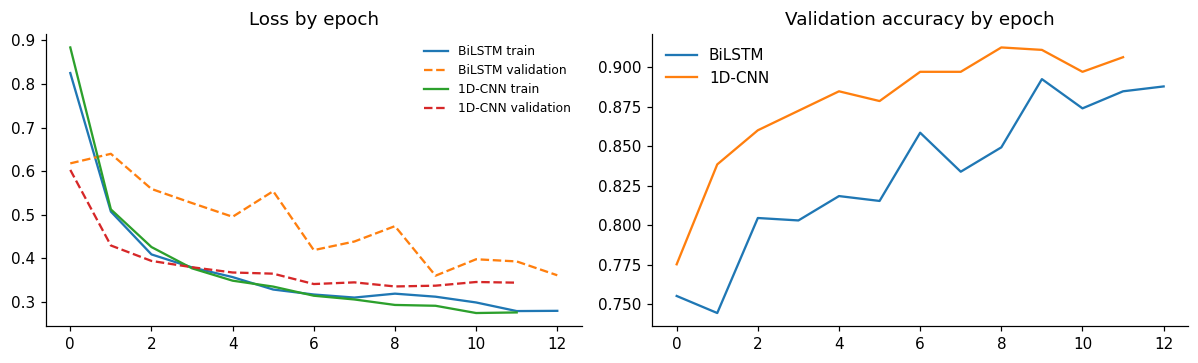

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for h, n in [(h_lstm, 'BiLSTM'), (h_cnn, '1D-CNN')]:
    axes[0].plot(h.history['loss'], label=f'{n} train'); axes[0].plot(h.history['val_loss'], '--', label=f'{n} validation')
    axes[1].plot(h.history['val_accuracy'], label=n)
axes[0].set_title('Loss by epoch'); axes[0].legend(frameon=False, fontsize=8); axes[1].set_title('Validation accuracy by epoch'); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 8. Results on the 800 unseen portfolio clauses

In [11]:
res = pd.DataFrame(results).set_index('model').sort_values('macro_F1', ascending=False); res

,macro_F1,accuracy,High_precision,High_recall,High_F1
model,,,,,
Neural network (1D-CNN),0.942,0.956,0.854,0.950,0.899
Neural network (MLP on TF-IDF),0.917,0.940,0.926,0.787,0.851
Neural network (BiLSTM),0.912,0.938,0.783,0.900,0.837
Logistic regression,0.858,0.906,0.637,0.812,0.714
Linear SVM,0.845,0.900,0.632,0.750,0.686
Naive Bayes,0.599,0.656,0.264,0.650,0.375
Keyword rules (baseline),0.379,0.388,0.180,0.750,0.290


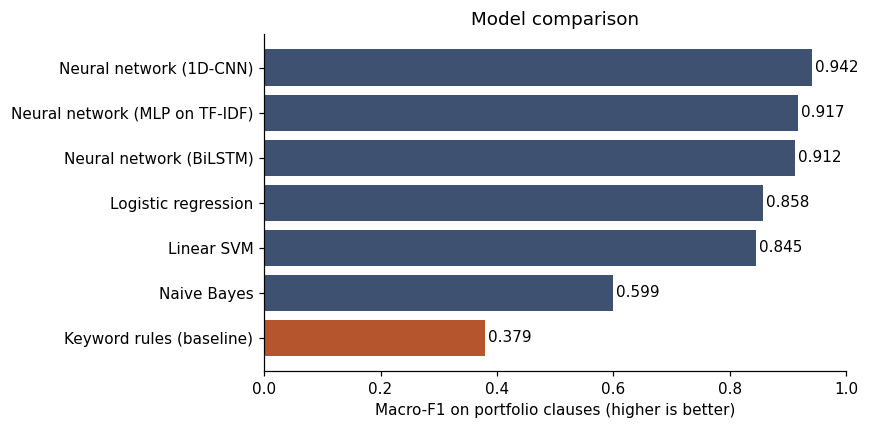

Best: Neural network (1D-CNN) (macro-F1 0.942), vs keyword rules 0.379


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
r = res.sort_values('macro_F1')
ax.barh(r.index, r.macro_F1, color=['#b4552e' if 'baseline' in n else '#3f5170' for n in r.index])
for i, v in enumerate(r.macro_F1): ax.text(v + .005, i, f'{v:.3f}', va='center')
ax.set_xlim(0, 1); ax.set_xlabel('Macro-F1 on portfolio clauses (higher is better)'); ax.set_title('Model comparison')
plt.tight_layout(); plt.show()
best = res.index[0]; print(f"Best: {best} (macro-F1 {res.loc[best,'macro_F1']}), vs keyword rules {res.loc['Keyword rules (baseline)','macro_F1']}")

**Reading the results**
- Every learned model beats the keyword checklist by a wide margin. Keywords miss context: "consequential" appears both in "shall **not** be liable for consequential loss" (safe) and "shall be liable for consequential loss" (risky).
- **The neural networks win.** The 1D-CNN and BiLSTM read words in order, so they can tell "within 30 days" from "within 120 days" and "shall be limited" from "shall not be limited". The CNN's filters act like learned phrase detectors, which suits short, formulaic legal text.
- **Logistic regression and SVM** on TF-IDF phrases are strong, explainable baselines, but they see a bag of phrases rather than a sentence, so they confuse Medium and High more often.
- **Naive Bayes** is fast but weak here: it assumes words are independent, which fails when risk depends on combinations like "notice" + "120 days".

## 9. Tuning for high-risk recall
A missed High clause can mean unlimited liability or months of unpaid bills. For the best model (1D-CNN) I choose the probability threshold for High that maximises **F2** on its validation clauses (never the test set). F2 counts recall twice as much as precision, so it favours catching risky clauses without flooding reviewers. Then I check the effect on the test set.

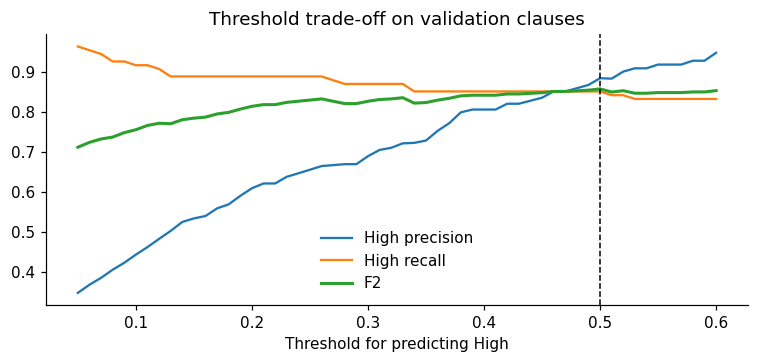

Best F2 threshold is 0.50: the default already gives the best recall-weighted balance, so no adjustment is applied.


,macro_F1,High_precision,High_recall
model,,,
Neural network (1D-CNN),0.942,0.854,0.95


In [13]:
p_val = cnn.predict(Xs_tr[val], verbose=0); yv = ys_tr[val]; H = LEVELS.index('High')
ths = np.round(np.linspace(0.05, 0.60, 56), 2)
from sklearn.metrics import fbeta_score
f2 = [fbeta_score(yv == H, p_val[:, H] >= t, beta=2) for t in ths]; TH = float(ths[int(np.argmax(f2))])
def with_threshold(p, th=TH):
    out = np.array(LEVELS)[p.argmax(1)].astype(object); out[p[:, H] >= th] = 'High'; return out
prec = [precision_score(yv == H, p_val[:, H] >= t, zero_division=0) for t in ths]; rec = [recall_score(yv == H, p_val[:, H] >= t) for t in ths]
fig, ax = plt.subplots(figsize=(7, 3.4)); ax.plot(ths, prec, label='High precision'); ax.plot(ths, rec, label='High recall'); ax.plot(ths, f2, label='F2', lw=2)
ax.axvline(TH, color='k', ls='--', lw=1); ax.set_xlabel('Threshold for predicting High'); ax.legend(frameon=False); ax.set_title('Threshold trade-off on validation clauses')
plt.tight_layout(); plt.show()
if abs(TH - 0.5) < 1e-9:
    FINAL = 'Neural network (1D-CNN)'
    print('Best F2 threshold is 0.50: the default already gives the best recall-weighted balance, so no adjustment is applied.')
else:
    FINAL = '1D-CNN, High threshold tuned'; preds[FINAL] = with_threshold(p_cnn); results.append(score(FINAL, preds[FINAL]))
    print(f'Chosen High threshold: {TH:.2f} (validation F2 = {max(f2):.3f})')
res = pd.DataFrame(results).set_index('model').sort_values('macro_F1', ascending=False)
res.loc[[FINAL], ['macro_F1', 'High_precision', 'High_recall']]

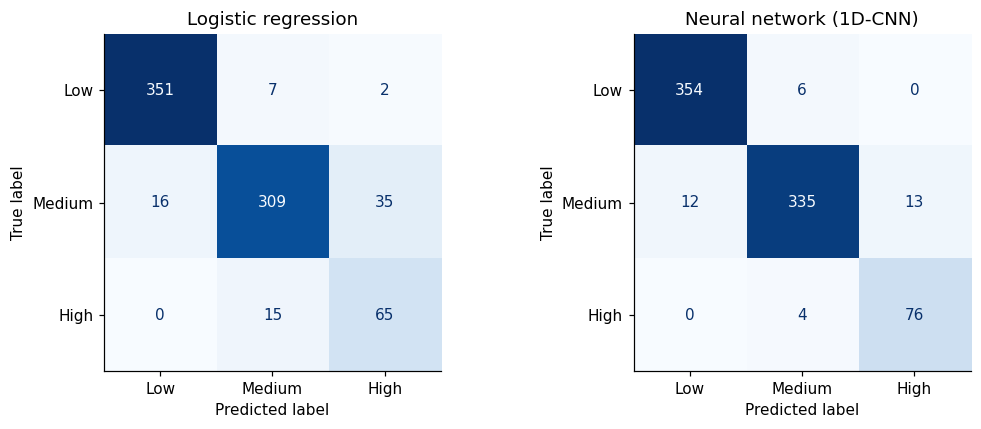

              precision    recall  f1-score   support

         Low       0.97      0.98      0.98       360
      Medium       0.97      0.93      0.95       360
        High       0.85      0.95      0.90        80

    accuracy                           0.96       800
   macro avg       0.93      0.95      0.94       800
weighted avg       0.96      0.96      0.96       800



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, n in zip(axes, ['Logistic regression', FINAL]):
    ConfusionMatrixDisplay(confusion_matrix(y_te, preds[n], labels=LEVELS), display_labels=LEVELS).plot(ax=ax, colorbar=False, cmap='Blues'); ax.set_title(n)
plt.tight_layout(); plt.show()
print(classification_report(y_te, preds[FINAL], labels=LEVELS))

The curve shows the trade-off: lowering the threshold catches slightly more High clauses but quickly sends many more Medium clauses for review, so precision collapses. On validation data, F2 peaks at the default threshold, so the app uses the CNN as trained. On the test set it catches 95% of High clauses (76 of 80) with 85% precision.

## 10. Explainability
**Linear model:** the phrases with the largest weights for each rating show what the data teaches.

In [15]:
best_lr = lr.best_estimator_; cls = list(best_lr.classes_)
vect = best_lr.named_steps['tfidfvectorizer']; clf = best_lr.named_steps['logisticregression']
feats = np.array(vect.get_feature_names_out())
pd.DataFrame({lvl: feats[np.argsort(clf.coef_[cls.index(lvl)])[::-1][:12]] for lvl in LEVELS})

,Low,Medium,High
0,30,within 60 days,within 180
1,within 45,price such,10
2,thirty days,contract price such,contractor
3,within forty five,price such liability,within one hundred
4,within forty,of termination any,clause contractor agrees
5,30 days,90 days of,within 120
6,one month,on fifteen,amounts within 120
7,month,cause on fifteen,10 percent
8,30 days prior,twenty days either,than 90 calendar
9,thirty,of contractor neither,within 150


**Neural network:** a CNN has no readable weights per word, so I use **occlusion**: blank out one word at a time and measure how much the probability of High drops. The words with the biggest drop are the ones the network relied on. The app shows the same highlighting for any clause.

In [16]:
def occlusion(text, k=6):
    t = normalise(text); seq = vec([t]).numpy(); n = min(len(t.split()), SEQ)
    base = cnn.predict(seq, verbose=0)[0]
    batch = np.repeat(seq, n, 0); batch[np.arange(n), np.arange(n)] = 0
    drop = base[H] - cnn.predict(batch, verbose=0)[:, H]
    toks = t.split()[:n]; top = np.argsort(drop)[::-1][:k]
    print('P(Low/Medium/High) = ' + ' / '.join(f'{v:.2f}' for v in base))
    print('Words the network relied on for High:', ', '.join(f'{toks[i]} ({drop[i]:+.2f})' for i in sorted(top)))
ex = test_df[test_df.risk_level == 'High'].clause_text.iloc[0]; print(ex, '\n'); occlusion(ex)

The Contractor agrees to fully indemnify the Company and its affiliates against all third-party claims, losses and expenses arising out of a breach of this Agreement, excluding indirect and consequential losses, without any limit as to amount, irrespective of whether such loss is caused wholly or partly by the negligence of the Company. The provisions of this Clause shall survive the expiry or termination of this Agreement. 



P(Low/Medium/High) = 0.00 / 0.02 / 0.98
Words the network relied on for High: fully (+0.04), indemnify (+0.02), employer (+0.04), and (+0.01), amount, (+0.01), irrespective (+0.02)


## 11. Error analysis and label noise

In [17]:
err = test_df.assign(pred=preds[FINAL])
err = err[err.pred != err.risk_level]
print(f'{len(err)} of {len(test_df)} clauses misclassified'); print(pd.crosstab(err.risk_level, err.pred, rownames=['actual'], colnames=['predicted']))
err[['clause_type', 'risk_level', 'pred', 'clause_text']].head(6)

35 of 800 clauses misclassified
predicted  High  Low  Medium
actual                      
High          0    0       4
Low           0    0       6
Medium       13   12       0


,clause_type,risk_level,pred,clause_text
7,Payment Terms,Medium,Low,"Save as otherwise expressly provided herein, payment shall be released within fifteen days from the date of certification of t..."
9,Auto-Renewal,High,Medium,"Upon expiry, the term shall stand extended by thirty-six (36) months on the same terms, unless terminated by notice served not..."
61,Payment Terms,High,Medium,"Save as otherwise expressly provided herein, the Client shall pay each certified invoice within 60 days of receipt. No interes..."
79,Payment Terms,Medium,High,The Employer shall make payment of undisputed amounts within 150 days of the invoice date. Any amendment to this Clause shall ...
114,Indemnity,Low,Medium,"Subject to Clause 10.8, the Service Provider shall keep the Company indemnified at all times against all third-party claims, l..."
117,Payment Terms,High,Medium,"Notwithstanding anything to the contrary contained in this Agreement, payment shall be released within one hundred and fifty d..."


In [18]:
oof = cross_val_predict(best_lr, train_df.text, y_tr, groups=groups, cv=gkf)   # fast linear model for a full cross-validated pass
cv_pred = oof
by_rev = train_df.assign(ok=cv_pred == y_tr).groupby('reviewer_id').ok.mean().mul(100).round(1)
print('Cross-validated agreement with each reviewer (%):'); by_rev.to_frame('agreement_%')

Cross-validated agreement with each reviewer (%):


,agreement_%
reviewer_id,
REV01,89.0
REV02,88.6
REV03,87.2
REV04,85.0
REV05,87.8
REV06,86.7


Most remaining errors are **Medium vs High** borderline clauses (for example a 90-day notice period, or a one-sided indemnity that is capped). In cross-validation, agreement is lowest with **REV04**, the stricter reviewer, which confirms that part of the remaining error is inconsistency in the human labels, not just the model. A real deployment should hold a calibration session so reviewers agree on the borderline rules.

## 12. Unsupervised: can the model discover clause topics on its own?
K-means on TF-IDF vectors, without being told the clause types, then compared with the real types.

Adjusted Rand index vs real clause types: 0.999 (1.0 = perfect match)


,cluster 0,cluster 1,cluster 2,cluster 3,cluster 4,cluster 5
0,shall,event,remedy,unless,shall,losses
1,payment,majeure,termination,renewal,loss,loss
2,retention,force,breach,expiry,liability,claims
3,running,party,days,term,liable,extent
4,payments,shall,convenience,automatically,price,indemnified
5,released,perform,shall,agreement,contract,indemnify


col_0,0,1,2,3,4,5
clause_type,,,,,,
Auto-Renewal,0,0,0,1089,0,0
Force Majeure,0,1096,0,0,0,0
Indemnity,0,0,0,0,0,1066
Liability Cap,0,0,0,2,1094,0
Payment Terms,1093,0,0,0,0,0
Termination,0,0,1073,0,0,0


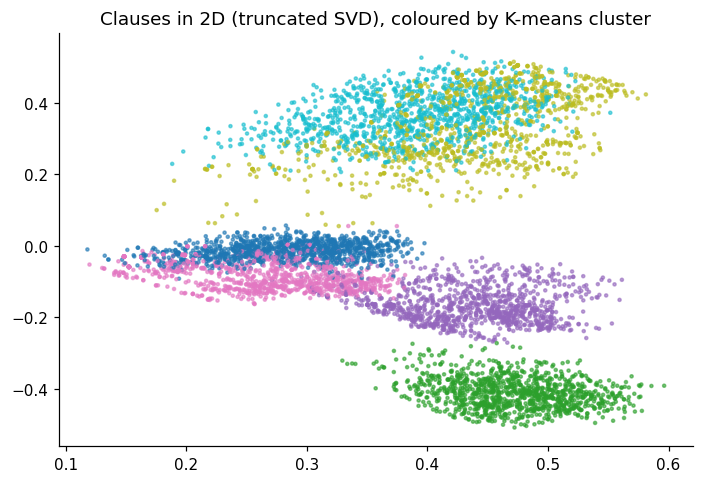

In [19]:
Xk = TfidfVectorizer(min_df=5, stop_words='english').fit(train_df.text)
Xt = Xk.transform(train_df.text)
km = KMeans(6, n_init=10, random_state=SEED).fit(Xt)
print('Adjusted Rand index vs real clause types:', round(adjusted_rand_score(train_df.clause_type, km.labels_), 3), '(1.0 = perfect match)')
kt = np.array(Xk.get_feature_names_out())
topics = pd.DataFrame({f'cluster {i}': kt[np.argsort(c)[::-1][:6]] for i, c in enumerate(km.cluster_centers_)})
display(topics); display(pd.crosstab(train_df.clause_type, km.labels_))
xy = TruncatedSVD(2, random_state=SEED).fit_transform(Xt)
fig, ax = plt.subplots(figsize=(6.5, 4.5)); ax.scatter(xy[:, 0], xy[:, 1], c=km.labels_, s=4, cmap='tab10', alpha=.6)
ax.set_title('Clauses in 2D (truncated SVD), coloured by K-means cluster'); plt.tight_layout(); plt.show()

## 13. Key-term extraction
Reviewers also want the numbers. Regular expressions pull the key commercial terms out of each portfolio clause into structured fields.

In [20]:
NUM = {'seven': 7, 'fourteen': 14, 'fifteen': 15, 'twenty-one': 21, 'thirty': 30, 'forty-five': 45, 'sixty': 60, 'seventy-five': 75, 'ninety': 90,
       'one hundred and twenty': 120, 'one hundred and fifty': 150, 'one hundred and eighty': 180}
def to_days(s):
    m = re.search(r'\((\d+)\) months|(\d+) months', s)
    if m: return int(m.group(1) or m.group(2)) * 30
    m = re.search(r'(\d+)', s)
    if m: return int(m.group(1))
    for w, n in sorted(NUM.items(), key=lambda kv: -len(kv[0])):
        if w in s: return n
DAY = r'((?:\d+|[a-z-]+(?: hundred and [a-z-]+)?)(?: \(\d+\))? (?:calendar )?(?:days|months?))'
def extract(t):
    t = normalise(t); out = {}
    m = re.search(r'(?:pay each|payment shall be released|settled|payment of undisputed amounts)[^.]*?within ' + DAY, t); out['payment_days'] = to_days(m.group(1)) if m else None
    m = re.search(r'(?:at least|not less than|in writing) ' + DAY, t); out['notice_days'] = to_days(m.group(1)) if m else None
    m = re.search(r'retain (\d+(?:\.\d+)?)|retention of (\d+(?:\.\d+)?)', t); out['retention_%'] = float(m.group(1) or m.group(2)) if m else None
    m = re.search(r'increase by (\d+)|escalation of (\d+)', t);  out['escalation_%'] = float(m.group(1) or m.group(2)) if m else None
    out['pay_when_paid'] = bool(re.search(r'pay-when-paid|back-to-back', t))
    out['unlimited_liability'] = bool(re.search(r'unlimited|not be limited|shall limit or exclude', t))
    return out
terms = pd.DataFrame([extract(t) for t in test_df.clause_text], index=test_df.clause_id)
print('Clauses with each term found:', {c: int(terms[c].notna().sum() if terms[c].dtype != bool else terms[c].sum()) for c in terms})
pd.concat([test_df.set_index('clause_id')[['clause_type']], terms], axis=1).dropna(how='all', subset=['payment_days', 'notice_days', 'retention_%']).head(8)

Clauses with each term found: {'payment_days': 140, 'notice_days': 104, 'retention_%': 100, 'escalation_%': 63, 'pay_when_paid': 14, 'unlimited_liability': 25}


,clause_type,payment_days,notice_days,retention_%,escalation_%,pay_when_paid,unlimited_liability
clause_id,,,,,,,
CLA000002,Auto-Renewal,NaN,120.0,NaN,NaN,False,False
CLA000004,Auto-Renewal,NaN,90.0,NaN,NaN,False,False
CLA000006,Payment Terms,150.0,NaN,5.0,NaN,True,False
CLA000007,Auto-Renewal,NaN,15.0,NaN,NaN,False,False
CLA000008,Payment Terms,15.0,NaN,7.5,NaN,False,False
CLA000010,Auto-Renewal,NaN,45.0,NaN,10.0,False,False
CLA000011,Payment Terms,30.0,NaN,NaN,NaN,False,False
CLA000014,Payment Terms,30.0,NaN,5.0,NaN,True,False


## 14. Contract review worklist
Clause predictions roll up to each portfolio contract so the legal team knows which contracts to read first.

In [21]:
pr = test_df.assign(pred=preds[FINAL], p_high=p_cnn[:, H])
wl = pr.groupby('contract_id').agg(clauses=('clause_id', 'size'), high_predicted=('pred', lambda s: (s == 'High').sum()),
                                   max_p_high=('p_high', 'max'), high_reviewer=('risk_level', lambda s: (s == 'High').sum())).reset_index()
wl = wl.merge(pc[['contract_id', 'contract_name', 'counterparty', 'contract_value', 'end_date', 'auto_renew']], on='contract_id')
wl = wl.sort_values(['high_predicted', 'max_p_high'], ascending=False)
caught = ((wl.high_reviewer > 0) & (wl.high_predicted > 0)).sum(); need = (wl.high_reviewer > 0).sum()
print(f'Contracts with at least one reviewer-rated High clause: {need}; flagged by the model: {caught} ({caught/need:.0%}).')
print(f'Contracts the model flags for priority review: {(wl.high_predicted > 0).sum()} of {len(wl)}.')
wl.head(10)

Contracts with at least one reviewer-rated High clause: 40; flagged by the model: 40 (100%).
Contracts the model flags for priority review: 52 of 200.


,contract_id,clauses,high_predicted,max_p_high,high_reviewer,contract_name,counterparty,contract_value,end_date,auto_renew
19,CON00020,4,3,0.975355,2,Consultancy Agreement 20,Suryodaya Electricals Pvt Ltd,52800000,2026-08-23,N
3,CON00004,4,2,0.999784,2,Services Agreement 4,Navdurga Infra Services Pvt Ltd,23800000,2026-05-07,N
25,CON00026,4,2,0.999570,2,Consultancy Agreement 26,Eastern Logistics Pvt Ltd,27500000,2026-04-18,Y
7,CON00008,4,2,0.996919,2,Consultancy Agreement 8,Vardhman Steel Traders Pvt Ltd,14200000,2025-12-02,N
5,CON00006,4,2,0.995788,2,Works Agreement 6,Pragati Logistics Pvt Ltd,29600000,2026-01-25,Y
1,CON00002,4,2,0.995368,2,Equipment Hire Agreement 2,Bharat MEP Systems Pvt Ltd,57300000,2026-07-29,N
21,CON00022,4,2,0.994067,2,Supply Agreement 22,Omkar MEP Systems Pvt Ltd,37600000,2026-05-09,N
8,CON00009,4,2,0.993808,2,Works Agreement 9,Triveni Formwork Solutions Pvt Ltd,74000000,2026-01-07,N
39,CON00040,4,2,0.993566,2,Services Agreement 40,Deccan Electricals Pvt Ltd,74300000,2025-06-03,N
22,CON00023,4,2,0.993389,2,Consultancy Agreement 23,Vardhman Ready Mix Pvt Ltd,66200000,2026-09-22,N


## 15. Export for the web app

In [22]:
W = {type(l).__name__: l.get_weights() for l in cnn.layers}
dense = [l for l in cnn.layers if isinstance(l, tf.keras.layers.Dense)]
r5 = lambda a: np.round(a.astype(float), 5).tolist()
export = {
  'vocab': vec.get_vocabulary(), 'seq_len': SEQ, 'levels': LEVELS, 'high_threshold': TH,
  'embedding': r5(W['Embedding'][0][:len(vec.get_vocabulary())]), 'conv_w': r5(W['Conv1D'][0]), 'conv_b': r5(W['Conv1D'][1]),
  'd1_w': r5(dense[0].get_weights()[0]), 'd1_b': r5(dense[0].get_weights()[1]), 'd2_w': r5(dense[1].get_weights()[0]), 'd2_b': r5(dense[1].get_weights()[1]),
  'results': res.reset_index().to_dict(orient='records'),
  'worklist': wl.assign(max_p_high=wl.max_p_high.round(3), end_date=wl.end_date.astype(str)).to_dict(orient='records'),
  'clauses': pr.assign(p_high=pr.p_high.round(3))[['clause_id', 'contract_id', 'clause_type', 'clause_text', 'risk_level', 'pred', 'p_high']].to_dict(orient='records'),
  'check': [{'text': t, 'proba': [round(float(v), 6) for v in cnn.predict(vec([normalise(t)]).numpy(), verbose=0)[0]]} for t in test_df.clause_text.iloc[::40]],
  'train_n': int(len(train_df)), 'test_n': int(len(test_df)), 'cv_by_reviewer': by_rev.to_dict(),
}
cnn.save('../model/clause_cnn.keras')
with open('../model/clause_model_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'))
print('Exported CNN with vocabulary of', len(export['vocab']), 'tokens')

Exported CNN with vocabulary of 748 tokens


## Summary
- **Data:** 6,513 readable historical clauses from 1,300 contracts for training; the 800 portfolio clauses for testing.
- **Models:** keyword baseline, Naive Bayes, Logistic Regression, Linear SVM, and three neural networks (MLP, BiLSTM, 1D-CNN), plus K-means topic discovery and rule-based term extraction.
- **Result:** the 1D-CNN is the most accurate model (macro-F1 0.94 against 0.38 for the keyword checklist and 0.86 for logistic regression). It catches 95% of high-risk clauses with 85% precision; the threshold analysis confirmed the default setting is the best trade-off (sections 8–9). Occlusion shows which words drove each rating.
- **Honest limits:** synthetic clauses are more regular than real contracts, and reviewer labels are noisy. A real deployment needs the client's own reviewed clauses, a reviewer calibration exercise, and a human decision on every flagged clause.